# Transition summaries

This notebook is intentionally concise:
- mean summaries only
- rotated 45 degree sectors instead of the old sign quadrants
- one figure style reused for `act`, `post/familiar`, and `post/novel`

In [30]:
from pathlib import Path

import importlib
import context_contrasting.data_analysis.transitions_helpers as th

# Force the live helper file to be reloaded in long-running notebook kernels.
th = importlib.reload(th)

build_mean_summary = th.build_mean_summary
DEFAULT_PLOT_STYLE = th.DEFAULT_PLOT_STYLE
compute_response_limits = th.compute_response_limits
compute_shift_limits = th.compute_shift_limits
load_transition_table = th.load_transition_table
plot_mean_transition_summary = th.plot_mean_transition_summary

PLOT_STYLE = DEFAULT_PLOT_STYLE | {
    "pre_point_alpha": 1.0,
    "target_point_alpha": 0.8,
    "shift_point_alpha": 1.0,
    "pre_vector_alpha": 0.5,
    "target_vector_alpha": 0.5,
    "individual_vector_width": 0.005,
    "mean_arrow_width": 3.1,
    "mean_arrow_mutation_scale": 16.5,
}

DATA_DIR = Path("context_contrasting/data_analysis")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

act_table = load_transition_table(DATA_DIR / "transitions_act.csv")
post_table = load_transition_table(DATA_DIR / "transitions_post.csv")

act_mean = build_mean_summary(act_table, image_group="all", pre_stage="Pre", target_stage="Task")
post_familiar_mean = build_mean_summary(post_table, image_group="familiar", pre_stage="Pre", target_stage="Post")
post_novel_mean = build_mean_summary(post_table, image_group="novel", pre_stage="Pre", target_stage="Post")

post_response_lims = compute_response_limits(post_familiar_mean, post_novel_mean)
post_shift_lims = compute_shift_limits(post_familiar_mean, post_novel_mean)


## Act mean


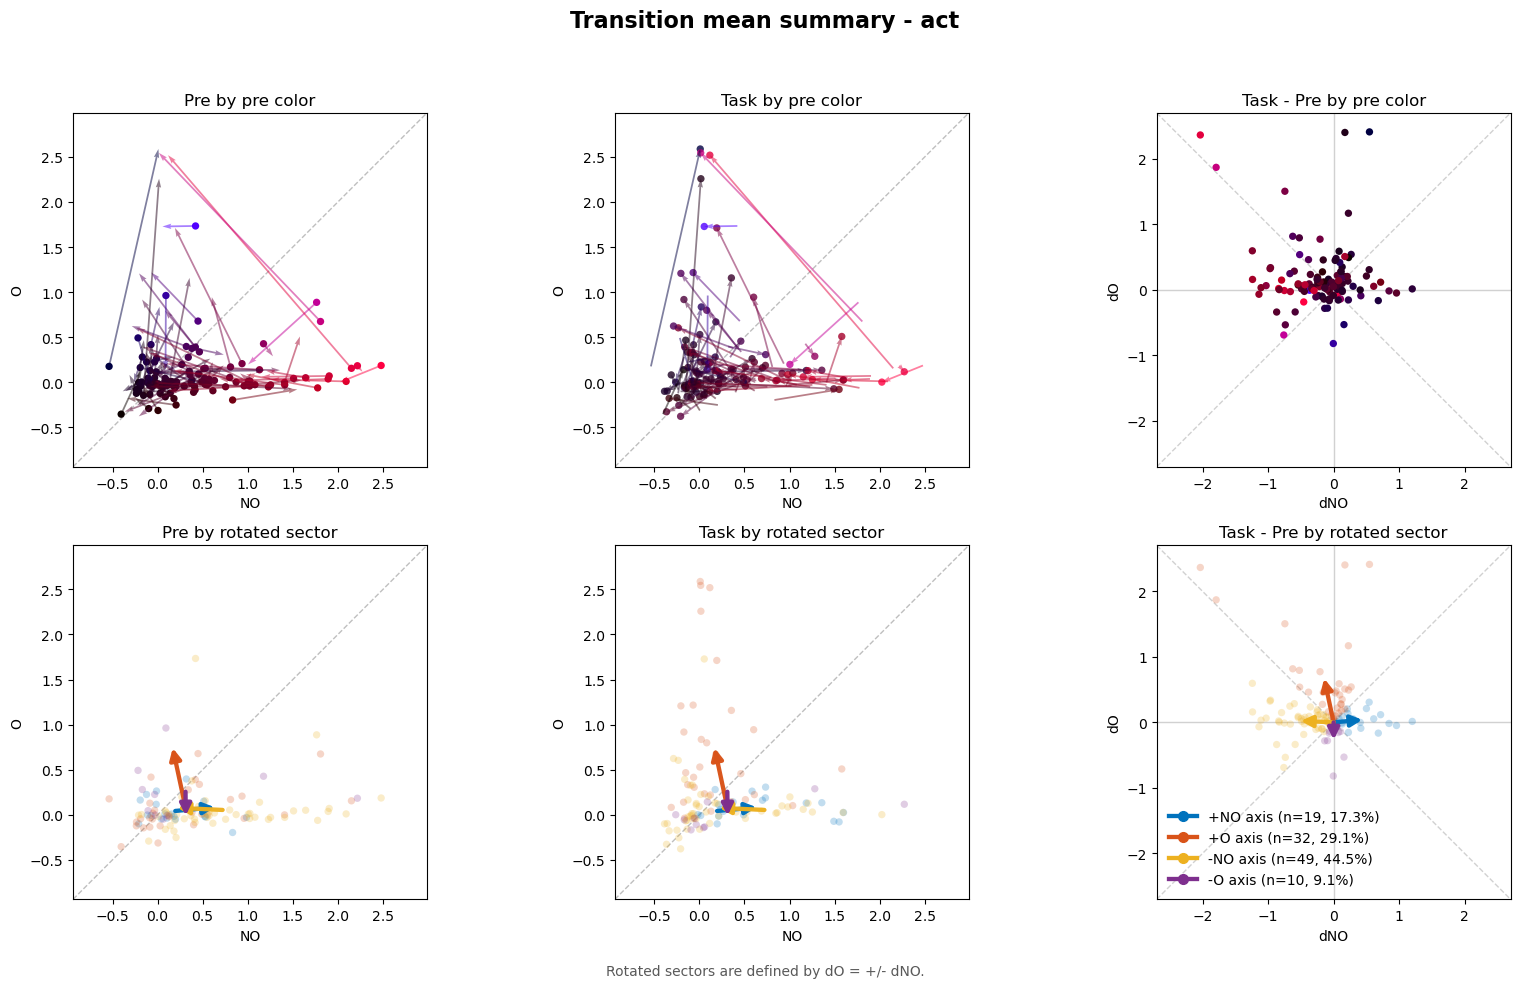

In [31]:
_ = plot_mean_transition_summary(
    act_mean,
    title="Transition mean summary - act",
    start_label="Pre",
    end_label="Task",
    style=PLOT_STYLE,
)


## Post mean: familiar


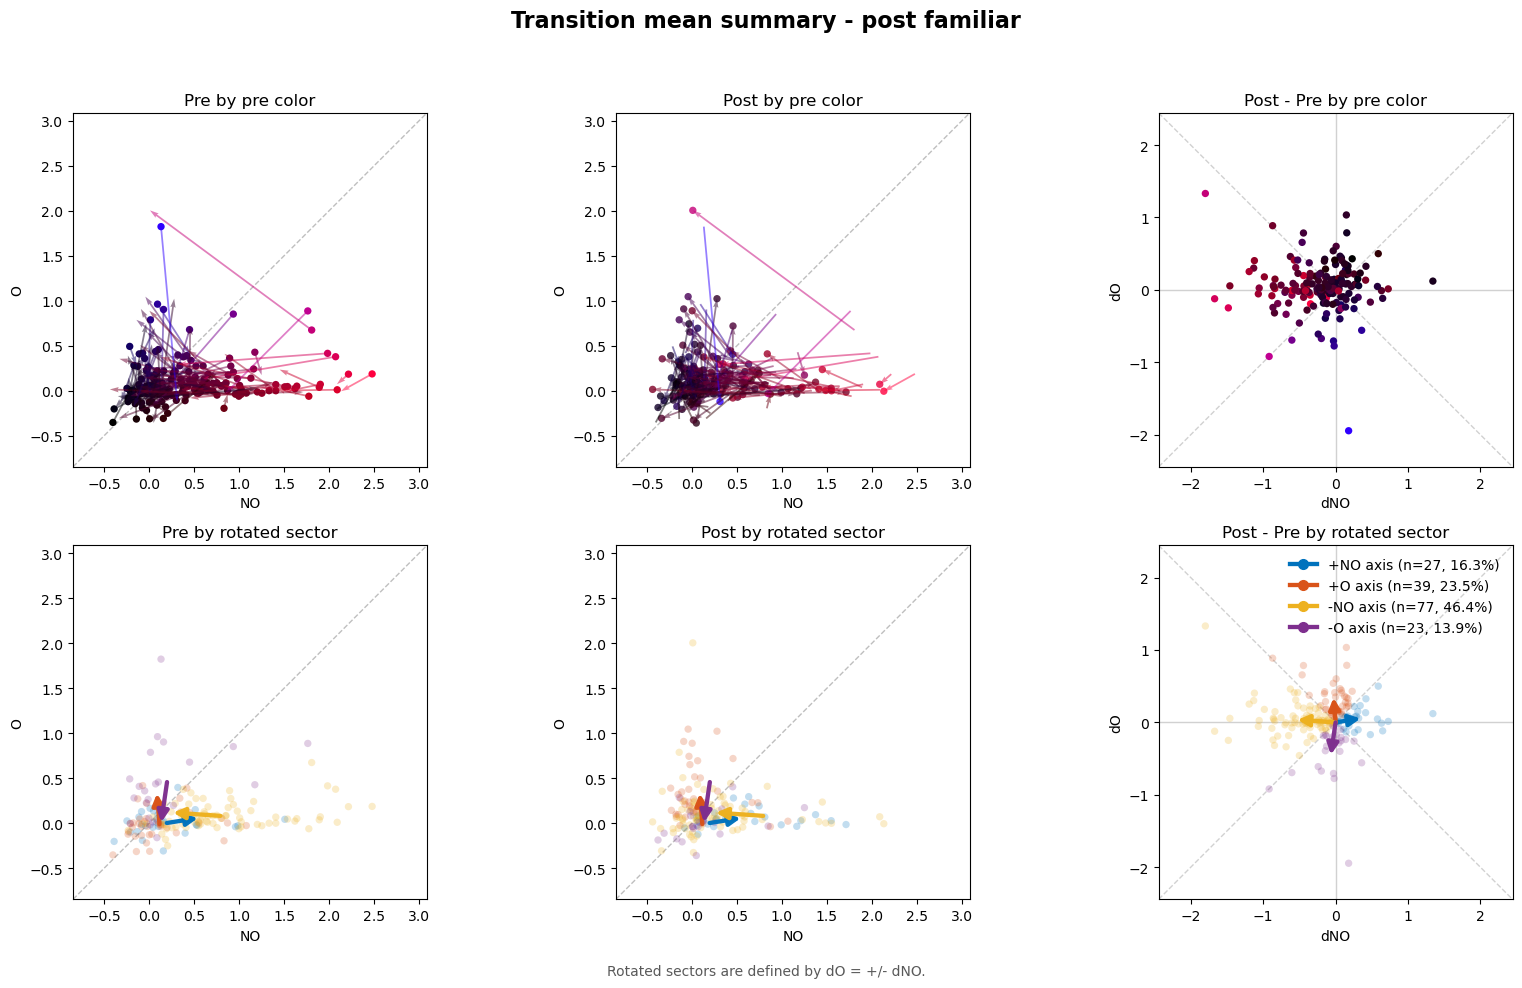

In [32]:
_ = plot_mean_transition_summary(
    post_familiar_mean,
    title="Transition mean summary - post familiar",
    start_label="Pre",
    end_label="Post",
    response_lims=post_response_lims,
    shift_lims=post_shift_lims,
    style=PLOT_STYLE,
)


## Post mean: novel


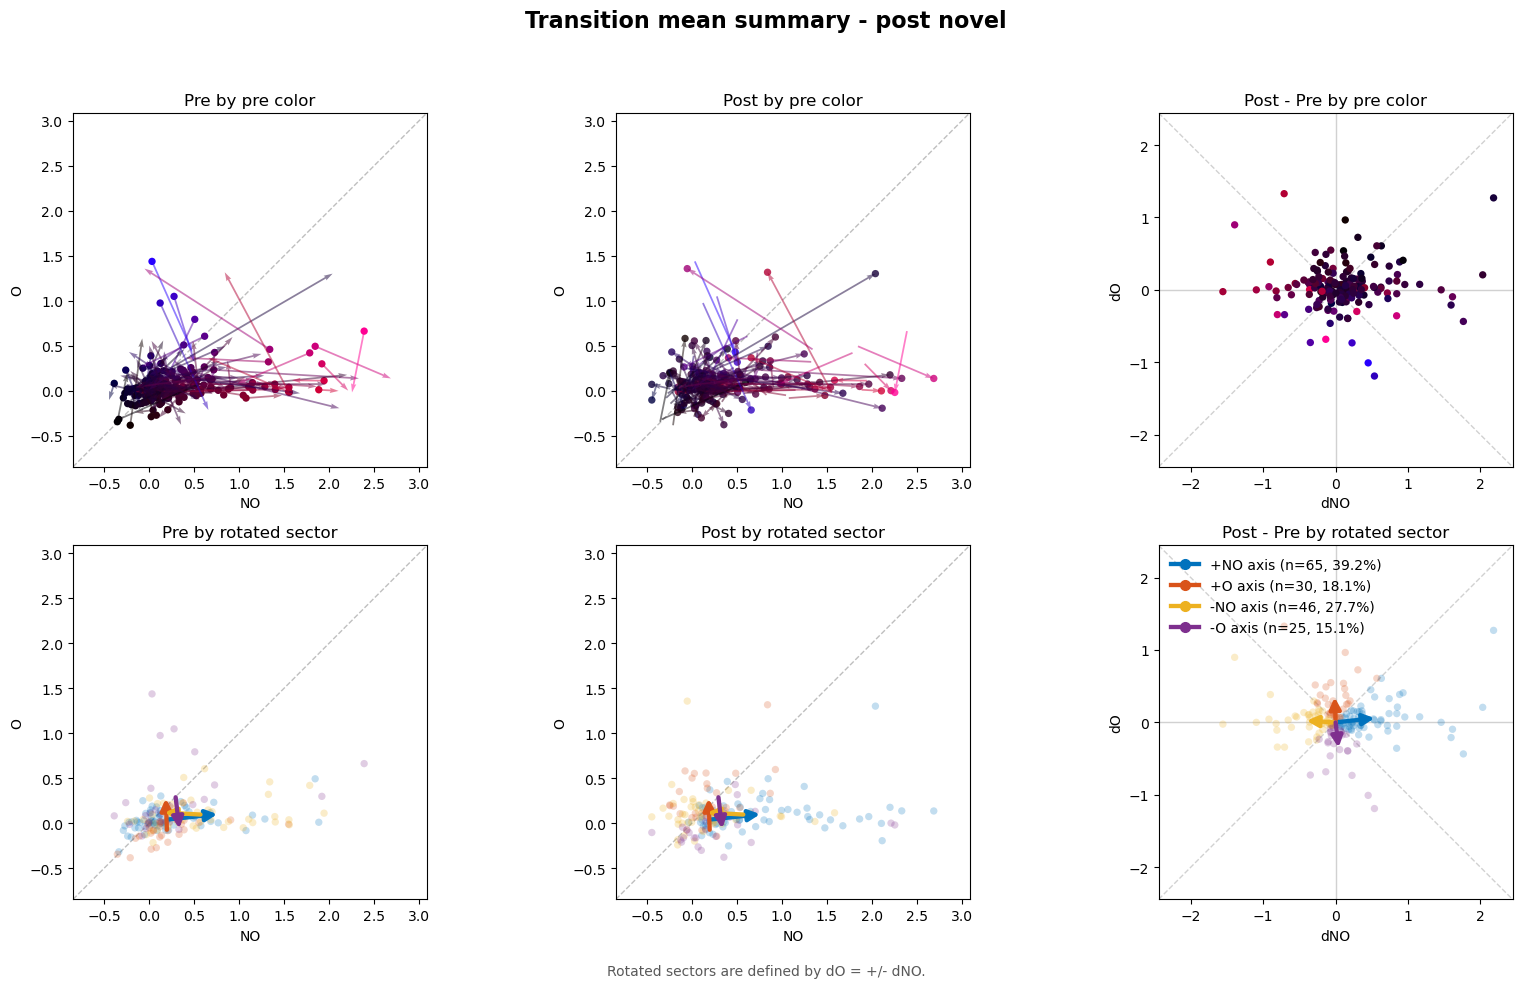

In [33]:
_ = plot_mean_transition_summary(
    post_novel_mean,
    title="Transition mean summary - post novel",
    start_label="Pre",
    end_label="Post",
    response_lims=post_response_lims,
    shift_lims=post_shift_lims,
    style=PLOT_STYLE,
)
